In [1]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
import math
# sklearn preprocessing for dealing with categorical variables
from sklearn.preprocessing import LabelEncoder

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go



from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src import utils  
from src.config import Config 

cfg = Config
TASK = cfg.TASK
ID = cfg.ID
TARGET = cfg.TARGET
# -------------------------------------------------------
print(f"Task: {TASK}")

sys.path contains: /home/ismail
Task: regression


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
train_logs = pd.read_csv(f'./train_logs.csv')
train_scores = pd.read_csv(f'./train_scores.csv')
test_logs = pd.read_csv(f'./test_logs.csv')



In [3]:
df_train = train_logs.merge(train_scores, on="id", suffixes=(None, None))

In [4]:


# train = pd.read_csv("train.csv")
# test = pd.read_csv("test_logs.csv")


# # target = cfg.TARGET
# # train = df_train.drop(columns=[target])
# # y_train = df_train[target]



# print("X_train shape:", train.shape)
# print("X_test shape:", test.shape)


In [5]:
# train_scores = pd.read_csv("train_scores.csv")

In [6]:


from typing import Counter
from scipy.stats import skew, kurtosis
from tqdm import tqdm
import re

class Preprocessor:
    
    def __init__(self, seed):
        self.seed = seed
        
        self.activities = ['Input', 'Remove/Cut', 'Nonproduction', 'Replace', 'Paste']
        self.events = ['q', 'Space', 'Backspace', 'Shift', 'ArrowRight', 'Leftclick', 'ArrowLeft', '.', ',', 
              'ArrowDown', 'ArrowUp', 'Enter', 'CapsLock', "'", 'Delete', 'Unidentified']
        self.text_changes = ['q', ' ', 'NoChange', '.', ',', '\n', "'", '"', '-', '?', ';', '=', '/', '\\', ':']
        self.punctuations = ['"', '.', ',', "'", '-', ';', ':', '?', '!', '<', '>', '/',
                        '@', '#', '$', '%', '^', '&', '*', '(', ')', '_', '+']
        self.gaps = [1, 2, 3, 5, 10, 20, 50]
#         self.gaps = [1, 2]
    
    def activity_counts(self, df):
        tmp_df = df.groupby('id').agg({'activity': list}).reset_index()
        ret = list()
        for li in tqdm(tmp_df['activity'].values):
            items = list(Counter(li).items())
            di = dict()
            for k in self.activities:
                di[k] = 0
            for item in items:
                k, v = item[0], item[1]
                if k in di:
                    di[k] = v
            ret.append(di)
        ret = pd.DataFrame(ret)
        cols = [f'activity_{i}_count' for i in range(len(ret.columns))]
        ret.columns = cols
        return ret


    def event_counts(self, df, colname):
        tmp_df = df.groupby('id').agg({colname: list}).reset_index()
        ret = list()
        for li in tqdm(tmp_df[colname].values):
            items = list(Counter(li).items())
            di = dict()
            for k in self.events:
                di[k] = 0
            for item in items:
                k, v = item[0], item[1]
                if k in di:
                    di[k] = v
            ret.append(di)
        ret = pd.DataFrame(ret)
        cols = [f'{colname}_{i}_count' for i in range(len(ret.columns))]
        ret.columns = cols
        return ret


    def text_change_counts(self, df):
        tmp_df = df.groupby('id').agg({'text_change': list}).reset_index()
        ret = list()
        for li in tqdm(tmp_df['text_change'].values):
            items = list(Counter(li).items())
            di = dict()
            for k in self.text_changes:
                di[k] = 0
            for item in items:
                k, v = item[0], item[1]
                if k in di:
                    di[k] = v
            ret.append(di)
        ret = pd.DataFrame(ret)
        cols = [f'text_change_{i}_count' for i in range(len(ret.columns))]
        ret.columns = cols
        return ret

    def match_punctuations(self, df):
        tmp_df = df.groupby('id').agg({'down_event': list}).reset_index()
        ret = list()
        for li in tqdm(tmp_df['down_event'].values):
            cnt = 0
            items = list(Counter(li).items())
            for item in items:
                k, v = item[0], item[1]
                if k in self.punctuations:
                    cnt += v
            ret.append(cnt)
        ret = pd.DataFrame({'punct_cnt': ret})
        return ret


    def get_input_words(self, df):
        tmp_df = df[(~df['text_change'].str.contains('=>'))&(df['text_change'] != 'NoChange')].reset_index(drop=True)
        tmp_df = tmp_df.groupby('id').agg({'text_change': list}).reset_index()
        tmp_df['text_change'] = tmp_df['text_change'].apply(lambda x: ''.join(x))
        tmp_df['text_change'] = tmp_df['text_change'].apply(lambda x: re.findall(r'q+', x))
        tmp_df['input_word_count'] = tmp_df['text_change'].apply(len)
        tmp_df['input_word_length_mean'] = tmp_df['text_change'].apply(lambda x: np.mean([len(i) for i in x] if len(x) > 0 else 0))
        tmp_df['input_word_length_max'] = tmp_df['text_change'].apply(lambda x: np.max([len(i) for i in x] if len(x) > 0 else 0))
        tmp_df['input_word_length_std'] = tmp_df['text_change'].apply(lambda x: np.std([len(i) for i in x] if len(x) > 0 else 0))
        tmp_df.drop(['text_change'], axis=1, inplace=True)
        return tmp_df
    
    def make_feats(self, df):
        
        print("Starting to engineer features")
        
        # initialize features dataframe
        feats = pd.DataFrame({'id': df['id'].unique().tolist()})
        
        # get shifted features
        # time shift
        print("Engineering time data")
        for gap in self.gaps:
            print(f"> for gap {gap}")
            df[f'up_time_shift{gap}'] = df.groupby('id')['up_time'].shift(gap)
            df[f'action_time_gap{gap}'] = df['down_time'] - df[f'up_time_shift{gap}']
        df.drop(columns=[f'up_time_shift{gap}' for gap in self.gaps], inplace=True)

        # cursor position shift
        print("Engineering cursor position data")
        for gap in self.gaps:
            print(f"> for gap {gap}")
            df[f'cursor_position_shift{gap}'] = df.groupby('id')['cursor_position'].shift(gap)
            df[f'cursor_position_change{gap}'] = df['cursor_position'] - df[f'cursor_position_shift{gap}']
            df[f'cursor_position_abs_change{gap}'] = np.abs(df[f'cursor_position_change{gap}'])
        df.drop(columns=[f'cursor_position_shift{gap}' for gap in self.gaps], inplace=True)

        # word count shift
        print("Engineering word count data")
        for gap in self.gaps:
            print(f"> for gap {gap}")
            df[f'word_count_shift{gap}'] = df.groupby('id')['word_count'].shift(gap)
            df[f'word_count_change{gap}'] = df['word_count'] - df[f'word_count_shift{gap}']
            df[f'word_count_abs_change{gap}'] = np.abs(df[f'word_count_change{gap}'])
        df.drop(columns=[f'word_count_shift{gap}' for gap in self.gaps], inplace=True)
        
        # get aggregate statistical features
        print("Engineering statistical summaries for features")
        # [(feature name, [ stat summaries to add ])]
        feats_stat = [
            ('event_id', ['max']),
            ('up_time', ['max']),
            ('action_time', ['sum', 'max', 'mean', 'std']),
            ('activity', ['nunique']),
            ('down_event', ['nunique']),
            ('up_event', ['nunique']),
            ('text_change', ['nunique']),
            ('cursor_position', ['nunique', 'max', 'mean']),
            ('word_count', ['nunique', 'max', 'mean'])]
        for gap in self.gaps:
            feats_stat.extend([
                (f'action_time_gap{gap}', ['max', 'min', 'mean', 'std', 'sum', skew, kurtosis]),
                (f'cursor_position_change{gap}', ['max', 'mean', 'std', 'sum', skew, kurtosis]),
                (f'word_count_change{gap}', ['max', 'mean', 'std', 'sum', skew, kurtosis])
            ])
        
        pbar = tqdm(feats_stat)
        for item in pbar:
            colname, methods = item[0], item[1]
            for method in methods:
                pbar.set_postfix()
                if isinstance(method, str):
                    method_name = method
                else:
                    method_name = method.__name__
                    
                pbar.set_postfix(column=colname, method=method_name)
                tmp_df = df.groupby(['id']).agg({colname: method}).reset_index().rename(columns={colname: f'{colname}_{method_name}'})
                feats = feats.merge(tmp_df, on='id', how='left')

        # counts
        print("Engineering activity counts data")
        tmp_df = self.activity_counts(df)
        feats = pd.concat([feats, tmp_df], axis=1)
        
        print("Engineering event counts data")
        tmp_df = self.event_counts(df, 'down_event')
        feats = pd.concat([feats, tmp_df], axis=1)
        tmp_df = self.event_counts(df, 'up_event')
        feats = pd.concat([feats, tmp_df], axis=1)
        
        print("Engineering text change counts data")
        tmp_df = self.text_change_counts(df)
        feats = pd.concat([feats, tmp_df], axis=1)
        
        print("Engineering punctuation counts data")
        tmp_df = self.match_punctuations(df)
        feats = pd.concat([feats, tmp_df], axis=1)

        # input words
        print("Engineering input words data")
        tmp_df = self.get_input_words(df)
        feats = pd.merge(feats, tmp_df, on='id', how='left')

        # compare feats
        print("Engineering ratios data")
        feats['word_time_ratio'] = feats['word_count_max'] / feats['up_time_max']
        feats['word_event_ratio'] = feats['word_count_max'] / feats['event_id_max']
        feats['event_time_ratio'] = feats['event_id_max']  / feats['up_time_max']
        feats['idle_time_ratio'] = feats['action_time_gap1_sum'] / feats['up_time_max']
        
        print("Done!")
        return feats



In [7]:
preprocessor = Preprocessor(seed=42)

print("-"*25)
print("Engineering features for training data")
print("-"*25)
train_feats = preprocessor.make_feats(train_logs)

print()
print("-"*25)
print("Engineering features for test data")
print("-"*25)
test_feats = preprocessor.make_feats(test_logs)

-------------------------
Engineering features for training data
-------------------------
Starting to engineer features
Engineering time data
> for gap 1
> for gap 2
> for gap 3
> for gap 5
> for gap 10
> for gap 20
> for gap 50
Engineering cursor position data
> for gap 1
> for gap 2
> for gap 3
> for gap 5
> for gap 10
> for gap 20
> for gap 50
Engineering word count data
> for gap 1
> for gap 2
> for gap 3
> for gap 5
> for gap 10
> for gap 20
> for gap 50
Engineering statistical summaries for features


100%|██████████| 30/30 [01:00<00:00,  2.02s/it, column=word_count_change50, method=kurtosis]     


Engineering activity counts data


100%|██████████| 2471/2471 [00:00<00:00, 16542.21it/s]


Engineering event counts data


...

Engineering text change counts data


100%|██████████| 3/3 [00:00<00:00, 40853.61it/s]


Engineering punctuation counts data


100%|██████████| 3/3 [00:00<00:00, 25627.11it/s]


Engineering input words data
Engineering ratios data
Done!


In [10]:
train_feats = train_feats.merge(train_scores, on='id', how='left')

In [11]:


# train_feats = train_feats.merge(train_scores, on='id', how='left')

train_feats.head()



,id,event_id_max,up_time_max,action_time_sum,action_time_max,action_time_mean,action_time_std,activity_nunique,down_event_nunique,up_event_nunique,...,punct_cnt,input_word_count,input_word_length_mean,input_word_length_max,input_word_length_std,word_time_ratio,word_event_ratio,event_time_ratio,idle_time_ratio,score
0,001519c8,2557,1801969,297243,2259,116.246774,91.797374,7,12,12,...,37,366,5.325137,20,3.487804,0.000142,0.100117,0.001419,0.832534,3.5
1,0022f953,2454,1788969,275391,1758,112.221271,55.431189,5,17,17,...,53,385,4.410390,33,3.199496,0.000181,0.131622,0.001372,0.828944,3.5
2,0042269b,4136,1771669,421201,3005,101.837766,82.383766,4,13,18,...,47,627,5.446571,25,3.474895,0.000228,0.097679,0.002335,0.759751,6.0
3,0059420b,1556,1404469,189596,806,121.848329,113.768226,5,15,15,...,18,251,4.609562,19,2.949601,0.000147,0.132391,0.001108,0.835531,2.0
4,0075873a,2531,1662472,313702,701,123.943896,62.082013,3,11,11,...,66,412,4.766990,18,2.986064,0.000152,0.099565,0.001522,0.764103,4.0


In [12]:

print(f"Shape of training data: {train_feats.shape}")
print(f"Shape of test data: {test_feats.shape}")



Shape of training data: (2471, 212)
Shape of test data: (3, 211)


In [13]:
train_feats

,id,event_id_max,up_time_max,action_time_sum,action_time_max,action_time_mean,action_time_std,activity_nunique,down_event_nunique,up_event_nunique,...,punct_cnt,input_word_count,input_word_length_mean,input_word_length_max,input_word_length_std,word_time_ratio,word_event_ratio,event_time_ratio,idle_time_ratio,score
0,001519c8,2557,1801969,297243,2259,116.246774,91.797374,7,12,12,...,37,366,5.325137,20,3.487804,0.000142,0.100117,0.001419,0.832534,3.5
1,0022f953,2454,1788969,275391,1758,112.221271,55.431189,5,17,17,...,53,385,4.410390,33,3.199496,0.000181,0.131622,0.001372,0.828944,3.5
2,0042269b,4136,1771669,421201,3005,101.837766,82.383766,4,13,18,...,47,627,5.446571,25,3.474895,0.000228,0.097679,0.002335,0.759751,6.0
3,0059420b,1556,1404469,189596,806,121.848329,113.768226,5,15,15,...,18,251,4.609562,19,2.949601,0.000147,0.132391,0.001108,0.835531,2.0
4,0075873a,2531,1662472,313702,701,123.943896,62.082013,3,11,11,...,66,412,4.766990,18,2.986064,0.000152,0.099565,0.001522,0.764103,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2466,ffb8c745,4739,1791649,499670,3323,105.437856,63.622575,4,13,13,...,88,734,4.915531,20,3.001989,0.000257,0.097278,0.002645,0.708572,3.5
2467,ffbef7e5,2604,1799174,214221,1144,82.266129,36.178818,4,11,11,...,63,470,4.085106,13,2.231589,0.000243,0.168203,0.001447,0.868855,4.0
2468,ffccd6fd,3063,1959363,231580,564,75.605615,63.494975,3,11,11,...,7,222,4.644144,15,2.707087,0.000103,0.065622,0.001563,0.869824,1.5
2469,ffec5b38,3242,1508504,289439,1388,89.277915,54.515788,3,15,15,...,70,500,5.294000,24,3.541689,0.000274,0.127390,0.002149,0.794947,5.0


In [14]:
from sklearn.model_selection import KFold


kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (_, val_idx) in enumerate(kfold.split(train_feats)):
    train_feats.loc[val_idx, "fold"] = fold

In [15]:
X = train_feats.drop(columns=['id', 'fold', 'score'])
Y = train_feats['score']


In [30]:
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_squared_error

# TODO: change this to CV OOF using kfold cross-validation instead of train test split
# can also change the categorical of parameters into "suggest_float"
def objective(trial,data=X,target=Y):
    
    train_x, test_x, train_y, test_y = train_test_split(data, target, test_size=0.2,random_state=42)
    param = {
        'metric': 'rmse', 
        'random_state': 42,
        'n_estimators': 5000,
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-3, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-3, 10.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 0.1, log=True),
        'num_leaves' : trial.suggest_int('num_leaves', 8, 64),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 100),
    }
    model = lgb.LGBMRegressor(**param)  
    
    # model.fit(train_x,train_y,eval_set=[(test_x,test_y)],early_stopping_rounds=100,verbose=False)
    #
    model.fit(
        train_x,
        train_y,
        eval_set=[(test_x, test_y)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(0)  # suppress logs
        ]
    )
    preds = model.predict(test_x)
    
    rmse = mean_squared_error(test_y, preds,squared=False)
    
    return rmse



In [31]:
study = optuna.create_study(direction='minimize', study_name='Optimize boosting hyperparameters')
study.optimize(objective, n_trials=20)
print('Best trial:', study.best_trial.params)

[I 2026-04-20 19:01:00,078] A new study created in memory with name: Optimize boosting hyperparameters


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32218
[LightGBM] [Info] Number of data points in the train set: 1976, number of used features: 166
[LightGBM] [Info] Start training from score 3.709008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

[I 2026-04-20 19:01:03,105] Trial 0 finished with value: 0.578606912258596 and parameters: {'reg_alpha': 0.44264555972357295, 'reg_lambda': 0.07736060505516387, 'colsample_bytree': 0.656080742271159, 'subsample': 0.7768639924577577, 'learning_rate': 0.0041348965840270905, 'num_leaves': 41, 'min_child_samples': 96}. Best is trial 0 with value: 0.578606912258596.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-20 19:01:03,705] Trial 1 finished with value: 0.5726580345123491 and parameters: {'reg_alpha': 0.03320831067172812, 'reg_lambda': 0.003989350788867151, 'colsample_bytree': 0.5169709557747082, 'subsample': 0.5591700188648522, 'learning_rate': 0.032511396370639926, 'num_leaves': 15, 'min_child_samples': 54}. Best is trial 1 with value: 0.5726580345123491.


...

Early stopping, best iteration is:
[601]	valid_0's rmse: 0.578549
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32218
[LightGBM] [Info] Number of data points in the train set: 1976, number of used features: 166
[LightGBM] [Info] Start training from score 3.709008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

[I 2026-04-20 19:02:06,032] Trial 18 finished with value: 0.5784636837019056 and parameters: {'reg_alpha': 0.004444961572312387, 'reg_lambda': 0.033288436572525185, 'colsample_bytree': 0.5706920201580709, 'subsample': 0.9106987561289102, 'learning_rate': 0.000690153469305311, 'num_leaves': 42, 'min_child_samples': 56}. Best is trial 16 with value: 0.5702307383350317.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32218
[LightGBM] [Info] Number of data points in the train set: 1976, number of used features: 166
[LightGBM] [Info] Start training from score 3.709008
Training until validation scores don't improve for 100 rounds


[I 2026-04-20 19:02:06,397] Trial 19 finished with value: 0.5755294127665089 and parameters: {'reg_alpha': 0.03773054820848656, 'reg_lambda': 0.00411616331982337, 'colsample_bytree': 0.8043477147505574, 'subsample': 0.8892464381912899, 'learning_rate': 0.03610771303738587, 'num_leaves': 12, 'min_child_samples': 36}. Best is trial 16 with value: 0.5702307383350317.


Early stopping, best iteration is:
[117]	valid_0's rmse: 0.575529
Best trial: {'reg_alpha': 0.0014020824836705552, 'reg_lambda': 0.005189962798892773, 'colsample_bytree': 0.5524761976584373, 'subsample': 0.8733985072112624, 'learning_rate': 0.04183903827457692, 'num_leaves': 14, 'min_child_samples': 34}


In [42]:
feature_names = list(
    filter(lambda x: x not in ['score', 'id', 'fold'], train_feats.columns))

best_params = {'reg_alpha': 0.30650185736659397, 
                'reg_lambda': 0.08235806165155644, 
                'colsample_bytree': 0.5547938642836329, 
                'subsample': 0.782269098248984, 
                'learning_rate': 0.02572229832068531, 
                'num_leaves': 14, 
                'min_child_samples': 43}

lgbm_params = {
    'metric': 'rmse', 
    'random_state': 42,
    'n_estimators': 50000, #50000
    **best_params
}

# [fold]: model
models_dict = {}

for fold in range(5):
    
    print(f"Training for FOLD {fold}")
    
    X_train = train_feats[train_feats["fold"] != fold][feature_names]
    Y_train = train_feats[train_feats["fold"] != fold]['score']

    X_val = train_feats[train_feats["fold"] == fold][feature_names]
    Y_val = train_feats[train_feats["fold"] == fold]['score']
    
    model = lgb.LGBMRegressor(**lgbm_params)

    model.fit(X_train,
              Y_train,
              eval_names=['train', 'valid'],
              eval_set=[(X_train, Y_train), (X_val, Y_val)],
            #   verbose=-1,
              eval_metric='rmse',
              callbacks=[
            # This is the key! 
            # If the RMSE doesn't improve for 100 rounds, stop training.
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100) # Print progress every 100 rounds
        ]
              )
    
    models_dict[fold] = model

Training for FOLD 0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32473
[LightGBM] [Info] Number of data points in the train set: 1976, number of used features: 167
[LightGBM] [Info] Start training from score 3.709008
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.5805	valid's rmse: 0.595706
[200]	train's rmse: 0.505782	valid's rmse: 0.587806
Early stopping, best iteration is:
[166]	train's rmse: 0.527847	valid's rmse: 0.586304
Training for FOLD 1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004005 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32428
[LightGBM] [Info] Number of data points in the train set: 1977, number of used features: 167
[LightGBM] [Info] Start training from score 3.714466
Training until validati

In [43]:
feature_importances_values = np.asarray([model.feature_importances_ for model in models_dict.values()]).mean(axis=0)
feature_importance_df = pd.DataFrame({'name': feature_names, 'importance': feature_importances_values})

feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(10)


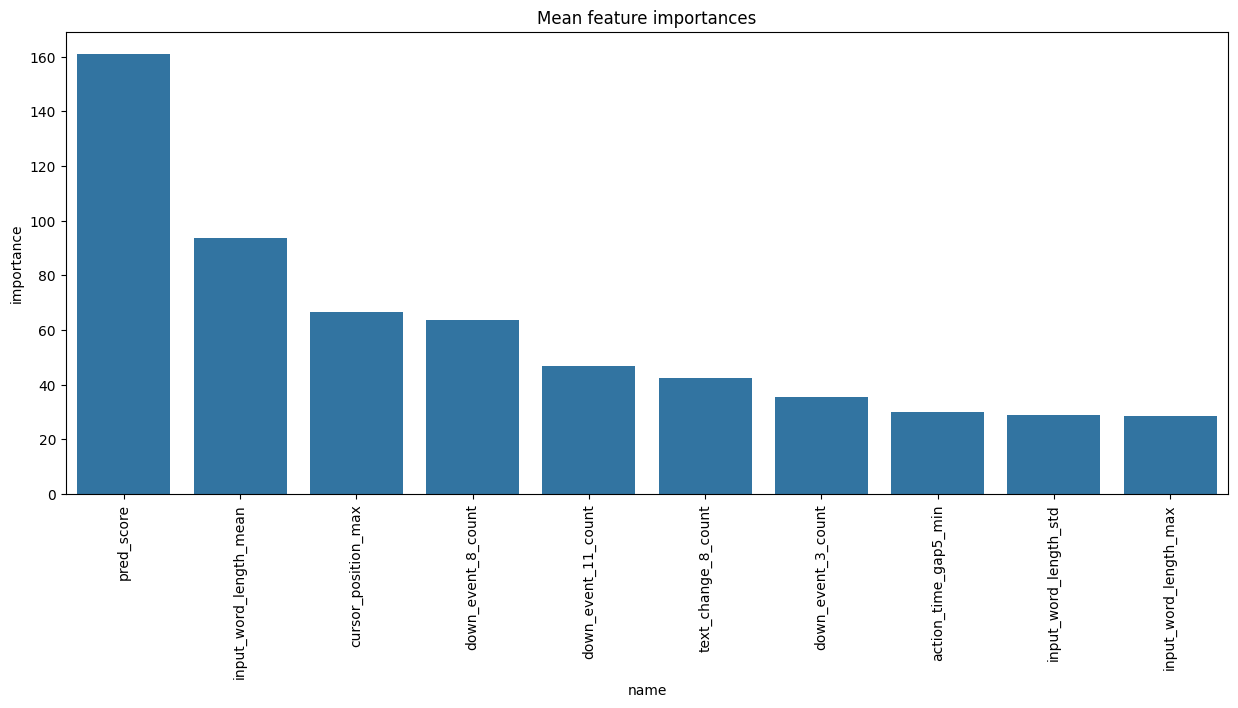

In [44]:
plt.figure(figsize=(15, 6))

ax = sns.barplot(data=feature_importance_df, x='name', y='importance')
ax.set_title(f"Mean feature importances")
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90)

plt.show()

In [45]:


for fold in range(5):
    print(f"Predicting the train set with FOLD {fold}")
    X_train = train_feats[train_feats["fold"] != fold][feature_names]
    Y_train = train_feats[train_feats["fold"] != fold]['score']

    X_val = train_feats[train_feats["fold"] == fold][feature_names]
    Y_val = train_feats[train_feats["fold"] == fold]['score']
    
    lgb_model = models_dict[fold]
    pred_val = lgb_model.predict(X_val, 
                                 num_iteration=lgb_model.best_iteration_)
    train_feats.loc[X_val.index, f"pred_{'score'}"] = pred_val



Predicting the train set with FOLD 0
Predicting the train set with FOLD 1
Predicting the train set with FOLD 2
Predicting the train set with FOLD 3
Predicting the train set with FOLD 4


In [46]:
rmse = mean_squared_error(train_feats['score'], 
                          np.clip(train_feats[f"pred_{'score'}"], a_min=0.5, a_max=6.0), 
                          squared=False)
print('CV RMSE:', rmse)


CV RMSE: 0.6544502480716498


In [27]:
for fold in range(5):
    print(f"Predicting the test set with FOLD {fold}")
    X_test = test_feats[feature_names]
    
    lgb_model = models_dict[fold]
    pred = lgb_model.predict(X_test, 
                            num_iteration=lgb_model.best_iteration_)
    test_feats[f"pred_{'score'}_fold{fold}"] = pred
    
test_feats['score'] = test_feats[[f"pred_{'score'}_fold{fold}"\
                                               for fold in range(5)]].mean(axis=1)
test_feats['score'] = np.clip(test_feats['score'], a_min=0.5, a_max=6.0)

Predicting the test set with FOLD 0
Predicting the test set with FOLD 1
Predicting the test set with FOLD 2
Predicting the test set with FOLD 3
Predicting the test set with FOLD 4


In [28]:


submission = test_feats[["id", 'score']]
submission



,id,score
0,0000aaaa,1.300981
1,2222bbbb,1.225950
2,4444cccc,1.252876


In [29]:
submission.to_csv('submission.csv', index=False)